# K-means,Modified K-means,h K-means,Fuzzy C means,DBSCAN,HDBSCAN,SOM

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

import skfuzzy as fuzz
import hdbscan
from minisom import MiniSom


# ============================================================
# LOAD IRIS DATASET
# ============================================================

iris = load_iris()

X = iris.data

print("Dataset shape:", X.shape)
print("Features:", iris.feature_names)


# ============================================================
# 1. K-MEANS
# ============================================================

print("\n========== K-MEANS ==========")

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

print("Cluster Labels:")
print(kmeans_labels)

print("\nCluster Centers:")
print(kmeans.cluster_centers_)


# ============================================================
# 2. MODIFIED K-MEANS
#    Farthest-point centroid initialization
# ============================================================

print("\n========== MODIFIED K-MEANS ==========")


def modified_kmeans(X, k=3, max_iterations=100):

    np.random.seed(42)

    # Select first centroid randomly
    first_index = np.random.randint(len(X))

    centroids = [X[first_index]]

    # Select remaining centroids using maximum distance
    for _ in range(1, k):

        distances = []

        for point in X:

            min_distance = min(
                np.linalg.norm(point - centroid)
                for centroid in centroids
            )

            distances.append(min_distance)

        next_centroid_index = np.argmax(distances)

        centroids.append(
            X[next_centroid_index]
        )

    centroids = np.array(centroids)

    # Standard K-Means iteration
    for iteration in range(max_iterations):

        # Distance of every point from every centroid
        distances = np.linalg.norm(
            X[:, np.newaxis] - centroids,
            axis=2
        )

        # Assign points to nearest centroid
        labels = np.argmin(
            distances,
            axis=1
        )

        # Calculate new centroids
        new_centroids = []

        for cluster_id in range(k):

            cluster_points = X[
                labels == cluster_id
            ]

            if len(cluster_points) > 0:

                new_centroid = np.mean(
                    cluster_points,
                    axis=0
                )

            else:

                new_centroid = centroids[
                    cluster_id
                ]

            new_centroids.append(
                new_centroid
            )

        new_centroids = np.array(
            new_centroids
        )

        # Stop when centroids no longer change
        if np.allclose(
            centroids,
            new_centroids
        ):
            break

        centroids = new_centroids

    return labels, centroids


modified_labels, modified_centers = modified_kmeans(
    X,
    k=3
)

print("Cluster Labels:")
print(modified_labels)

print("\nCluster Centers:")
print(modified_centers)


# ============================================================
# 3. HIERARCHICAL CLUSTERING
# ============================================================

print("\n========== HIERARCHICAL ==========")

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X
)

print("Cluster Labels:")
print(hierarchical_labels)


# ============================================================
# 4. FUZZY C-MEANS
# ============================================================

print("\n========== FUZZY C-MEANS ==========")

# Fuzzy C-Means expects:
# features x samples
X_fuzzy = X.T

centers, membership, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_fuzzy,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000,
    seed=42
)

# Highest membership determines cluster
fuzzy_labels = np.argmax(
    membership,
    axis=0
)

print("Cluster Labels:")
print(fuzzy_labels)

print("\nCluster Centers:")
print(centers)

print("\nMembership of first 5 samples:")
print(membership[:, :5])


# ============================================================
# 5. DBSCAN
# ============================================================

print("\n========== DBSCAN ==========")

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X
)

print("Cluster Labels:")
print(dbscan_labels)

print(
    "Clusters found:",
    set(dbscan_labels)
)

# -1 means noise/outlier


# ============================================================
# 6. HDBSCAN
# ============================================================

print("\n========== HDBSCAN ==========")

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=5
)

hdbscan_labels = hdbscan_model.fit_predict(
    X
)

print("Cluster Labels:")
print(hdbscan_labels)

print(
    "Clusters found:",
    set(hdbscan_labels)
)

# -1 means noise/outlier


# ============================================================
# 7. SELF-ORGANIZING MAP (SOM)
# ============================================================

print("\n========== SOM ==========")

# 1 x 3 SOM -> three neurons/clusters

som = MiniSom(
    x=1,
    y=3,
    input_len=4,
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(X)

som.train_random(
    X,
    num_iteration=1000
)

som_labels = []

for sample in X:

    winner = som.winner(sample)

    # winner = (row, column)
    cluster = winner[1]

    som_labels.append(cluster)

som_labels = np.array(som_labels)

print("Cluster Labels:")
print(som_labels)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n========== SUMMARY ==========")

print(
    "K-Means clusters:",
    np.unique(kmeans_labels)
)

print(
    "Modified K-Means clusters:",
    np.unique(modified_labels)
)

print(
    "Hierarchical clusters:",
    np.unique(hierarchical_labels)
)

print(
    "Fuzzy C-Means clusters:",
    np.unique(fuzzy_labels)
)

print(
    "DBSCAN clusters:",
    np.unique(dbscan_labels)
)

print(
    "HDBSCAN clusters:",
    np.unique(hdbscan_labels)
)

print(
    "SOM clusters:",
    np.unique(som_labels)
)

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

========== K-MEANS ==========
Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

Cluster Centers:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]

========== MODIFIED K-MEANS ==========
Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]

Cluster

In [2]:
def plot_clusters(X, labels, title):
    plt.figure(figsize=(7, 5))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=50
    )

    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title(title)
    plt.grid(alpha=0.2)

    plt.show()

kmeans

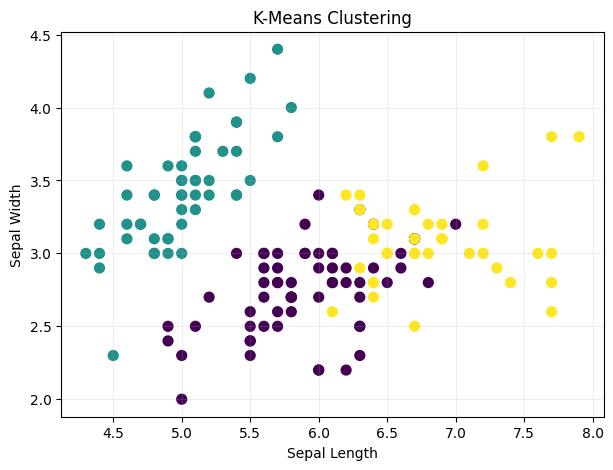

In [3]:
plot_clusters(
    X,
    kmeans_labels,
    "K-Means Clustering"
)

modified kmeans

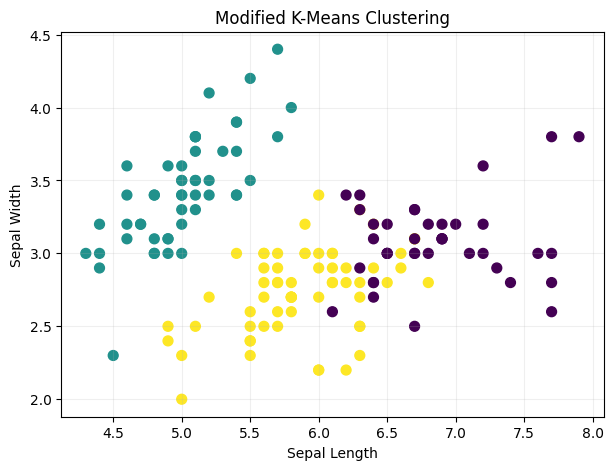

In [4]:
plot_clusters(
    X,
    modified_labels,
    "Modified K-Means Clustering"
)

Hierarchical Clustering

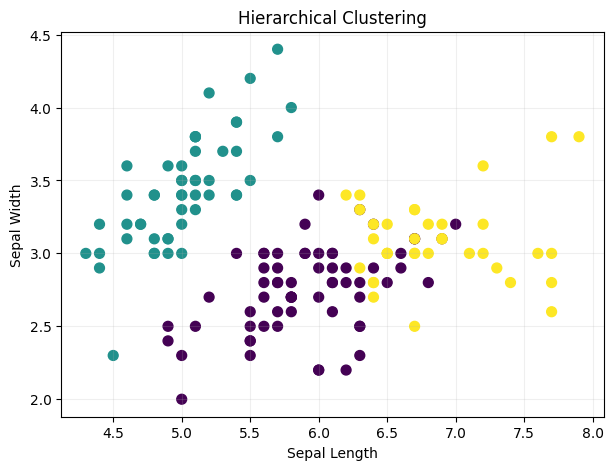

In [5]:
plot_clusters(
    X,
    hierarchical_labels,
    "Hierarchical Clustering"
)

Fuzzy C-Means

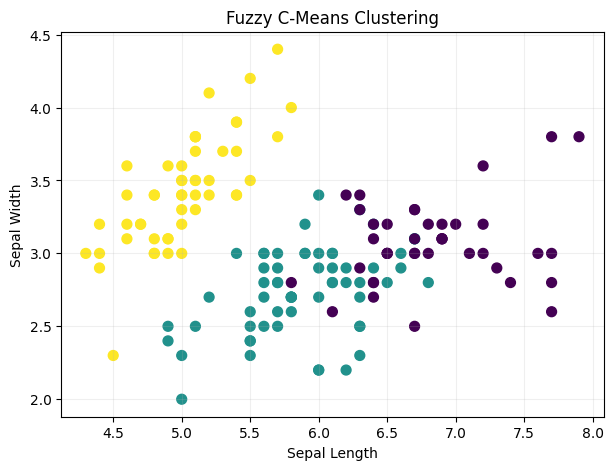

In [6]:
plot_clusters(
    X,
    fuzzy_labels,
    "Fuzzy C-Means Clustering"
)

DBSCAN

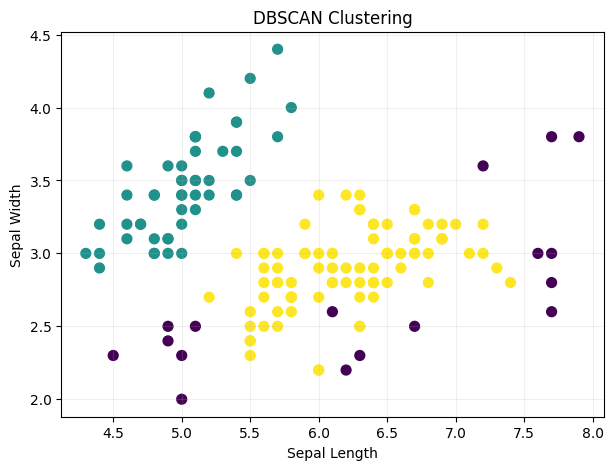

In [7]:
plot_clusters(
    X,
    dbscan_labels,
    "DBSCAN Clustering"
)

HDBSCAN

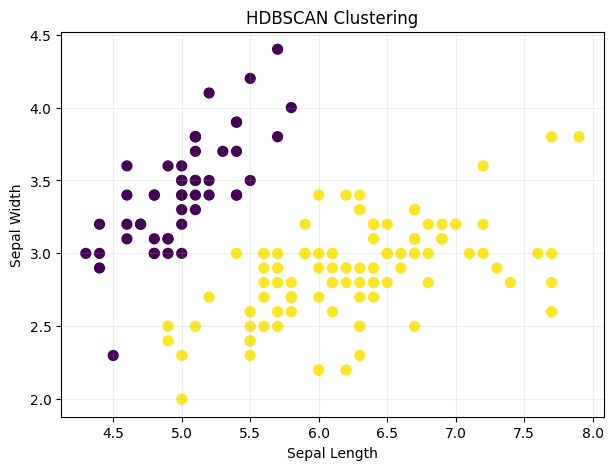

In [8]:
plot_clusters(
    X,
    hdbscan_labels,
    "HDBSCAN Clustering"
)

SOM

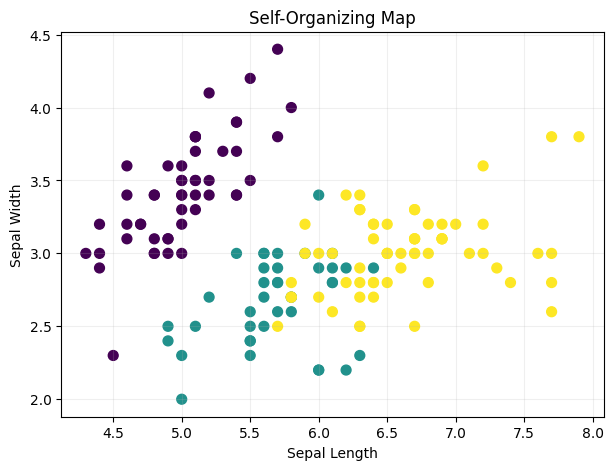

In [9]:
plot_clusters(
    X,
    som_labels,
    "Self-Organizing Map"
)

# Self-Training, Random Forest Classifier (RFC),XGBoost,AdaBoost,CatBoost,MLP,SVM

In [10]:
pip install scikit-learn xgboost catboost matplotlib

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 4.1 MB/s eta 0:00:25
   ---------------------------------------- 1.0/100.2 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 1.8/100.2 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 2.9/100.2 MB 3.6 MB/s eta 0:00:27
   - -------------------------------------- 3.7/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.7/100.2 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 5.5/100.2 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 6.0/100.2 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 6.8/100.2 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 7.6/100.2 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 8.1/100.2 MB 3.7 MB/s eta 0:00:25
   --- ------------------------------------ 8.9/100.2 MB 3.7 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']

Number of Features: 30

========== SELF-TRAINING ==========
Accuracy: 0.9122807017543859

========== RANDOM FOREST ==========
Accuracy: 0.956140350877193

========== XGBOOST ==========
Accuracy: 0.956140350877193

========== ADABOOST ==========
Accuracy: 0.956140350877193

========== CATBOOST ==========
Accuracy: 0.956140350877193

========== MLP ==========
Accuracy: 0.9649122807017544

========== SVM ==========
Accuracy: 0.9824561403508771

========== FINAL RESULTS ==========
Self Training : 91.23 %
Random Forest : 95.61 %
XGBoost : 95.61 %
AdaBoost : 95.61 %
CatBoost : 95.61 %
MLP : 96.49 %
SVM : 98.25 %


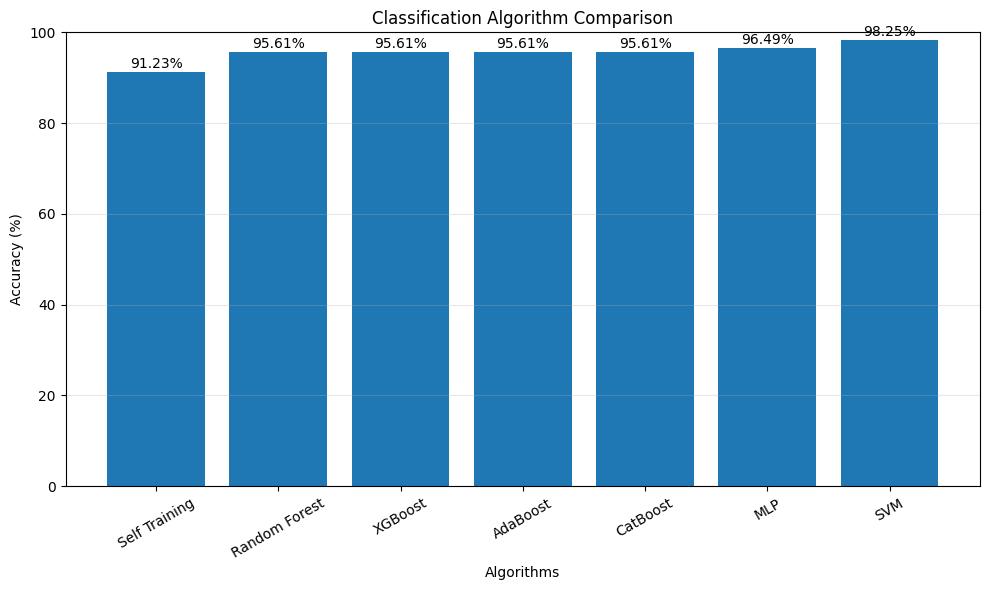

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ============================================================
# LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

print("\nNumber of Features:", len(data.feature_names))


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Store accuracy of each algorithm
results = {}


# ============================================================
# 1. SELF-TRAINING
# ============================================================

print("\n========== SELF-TRAINING ==========")

# Copy training labels
y_semi = y_train.copy()

# Randomly remove 70% labels
rng = np.random.RandomState(42)

unlabeled_indices = rng.choice(
    len(y_semi),
    size=int(len(y_semi) * 0.70),
    replace=False
)

# -1 means unlabeled
y_semi[unlabeled_indices] = -1


# Base classifier
base_model = SVC(
    probability=True,
    random_state=42
)

self_training = SelfTrainingClassifier(
    base_model
)

self_training.fit(
    X_train,
    y_semi
)

prediction = self_training.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["Self Training"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 2. RANDOM FOREST CLASSIFIER
# ============================================================

print("\n========== RANDOM FOREST ==========")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

prediction = rf.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["Random Forest"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 3. XGBOOST
# ============================================================

print("\n========== XGBOOST ==========")

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

prediction = xgb.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["XGBoost"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 4. ADABOOST
# ============================================================

print("\n========== ADABOOST ==========")

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

prediction = ada.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["AdaBoost"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 5. CATBOOST
# ============================================================

print("\n========== CATBOOST ==========")

cat = CatBoostClassifier(
    iterations=100,
    verbose=0,
    random_seed=42
)

cat.fit(
    X_train,
    y_train
)

prediction = cat.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["CatBoost"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 6. MULTILAYER PERCEPTRON (MLP)
# ============================================================

print("\n========== MLP ==========")

mlp = make_pipeline(
    StandardScaler(),

    MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=1000,
        random_state=42
    )
)

mlp.fit(
    X_train,
    y_train
)

prediction = mlp.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["MLP"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# 7. SUPPORT VECTOR MACHINE (SVM)
# ============================================================

print("\n========== SVM ==========")

svm = make_pipeline(
    StandardScaler(),

    SVC(
        kernel="rbf",
        random_state=42
    )
)

svm.fit(
    X_train,
    y_train
)

prediction = svm.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    prediction
)

results["SVM"] = accuracy

print("Accuracy:", accuracy)


# ============================================================
# RESULTS
# ============================================================

print("\n========== FINAL RESULTS ==========")

for model, accuracy in results.items():

    print(
        model,
        ":",
        round(accuracy * 100, 2),
        "%"
    )


# ============================================================
# MATPLOTLIB GRAPH
# ============================================================

names = list(results.keys())

accuracies = [
    value * 100
    for value in results.values()
]

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    names,
    accuracies
)

plt.xlabel(
    "Algorithms"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Classification Algorithm Comparison"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Show percentage above bars
for bar, accuracy in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 1,

        f"{accuracy:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()

# Random Forest Regression (RFR),Generalized Regression Neural Network (GRNN)

Dataset Shape: (442, 10)
Number of Features: 10

========== RANDOM FOREST REGRESSION ==========
MSE: 2952.0105887640448
R2 Score: 0.4428225673999313


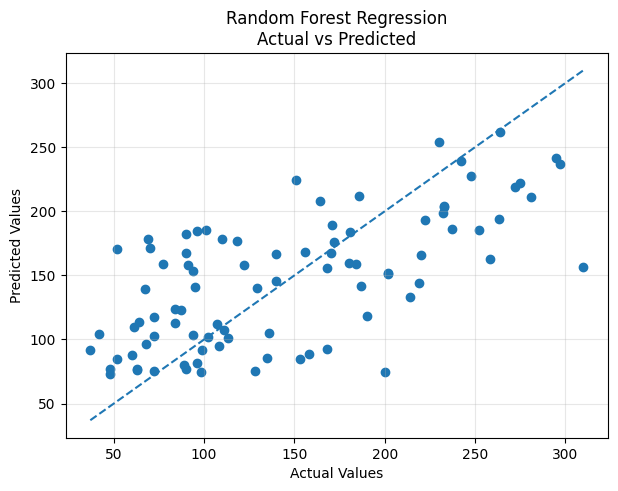


========== GRNN ==========
MSE: 5211.329799668661
R2 Score: 0.0163872144417625


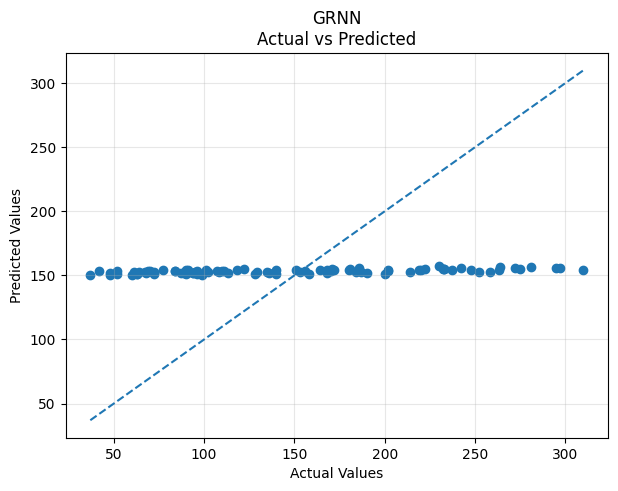

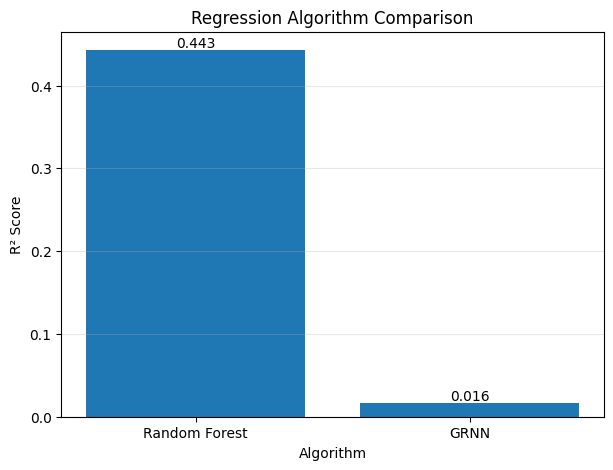

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# LOAD DIABETES DATASET
# ============================================================

data = load_diabetes()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 1. RANDOM FOREST REGRESSION
# ============================================================

print("\n========== RANDOM FOREST REGRESSION ==========")

rfr = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rfr.fit(
    X_train,
    y_train
)

rfr_prediction = rfr.predict(
    X_test
)


# Evaluation

rfr_mse = mean_squared_error(
    y_test,
    rfr_prediction
)

rfr_r2 = r2_score(
    y_test,
    rfr_prediction
)


print("MSE:", rfr_mse)
print("R2 Score:", rfr_r2)


# ============================================================
# RANDOM FOREST GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    rfr_prediction
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    "Random Forest Regression\nActual vs Predicted"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 2. GENERALIZED REGRESSION NEURAL NETWORK (GRNN)
# ============================================================

print("\n========== GRNN ==========")


def grnn_predict(
    X_train,
    y_train,
    X_test,
    sigma=0.5
):

    predictions = []

    for test_sample in X_test:

        # Calculate squared distance
        distances = np.sum(
            (X_train - test_sample) ** 2,
            axis=1
        )

        # Gaussian weights
        weights = np.exp(
            -distances /
            (2 * sigma ** 2)
        )

        # GRNN prediction
        prediction = (
            np.sum(weights * y_train)
            /
            np.sum(weights)
        )

        predictions.append(
            prediction
        )

    return np.array(
        predictions
    )


# ============================================================
# GRNN PREDICTION
# ============================================================

grnn_prediction = grnn_predict(
    X_train,
    y_train,
    X_test,
    sigma=0.5
)


# Evaluation

grnn_mse = mean_squared_error(
    y_test,
    grnn_prediction
)

grnn_r2 = r2_score(
    y_test,
    grnn_prediction
)


print("MSE:", grnn_mse)
print("R2 Score:", grnn_r2)


# ============================================================
# GRNN GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    grnn_prediction
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    "GRNN\nActual vs Predicted"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# COMPARISON
# ============================================================

models = [
    "Random Forest",
    "GRNN"
]

r2_scores = [
    rfr_r2,
    grnn_r2
]


plt.figure(figsize=(7, 5))

bars = plt.bar(
    models,
    r2_scores
)

plt.xlabel("Algorithm")
plt.ylabel("R² Score")

plt.title(
    "Regression Algorithm Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)


for bar, score in zip(
    bars,
    r2_scores
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{score:.3f}",

        ha="center",
        va="bottom"
    )


plt.show()

# Recurrent Neural Network (RNN)

In [13]:
pip install tensorflow statsmodels matplotlib scikit-learn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 3.2 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 2.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/11.3 MB 2.9 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.3 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.3 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.3 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 3.0 MB/s eta 0:00:03
   ----------------- ---------------------- 5.0/11.3 MB 3.1 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.3 MB 3.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 2.9 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 2.9 MB/s eta 0:00:02
   ---

     YEAR  SUNACTIVITY
0  1700.0          5.0
1  1701.0         11.0
2  1702.0         16.0
3  1703.0         23.0
4  1704.0         36.0

Dataset Shape: (309, 2)

X Shape: (297, 12, 1)
y Shape: (297,)

Training Samples: 237
Testing Samples: 60
Epoch 1/100


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3234.8662 - val_loss: 5178.1001
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3139.7368 - val_loss: 5052.7432
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3051.2554 - val_loss: 4947.7646
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2961.5291 - val_loss: 4818.7983
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2871.9268 - val_loss: 4702.6479
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2769.7351 - val_loss: 4533.7930
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2629.1304 - val_loss: 4341.2222
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2544.0613 - val_loss: 4269.4062
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2493.7483 - val_loss: 4195.7368
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2442.5579 - val_loss: 4127.9419
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2395.3127 - val_loss: 4063.8464
Epoch 12

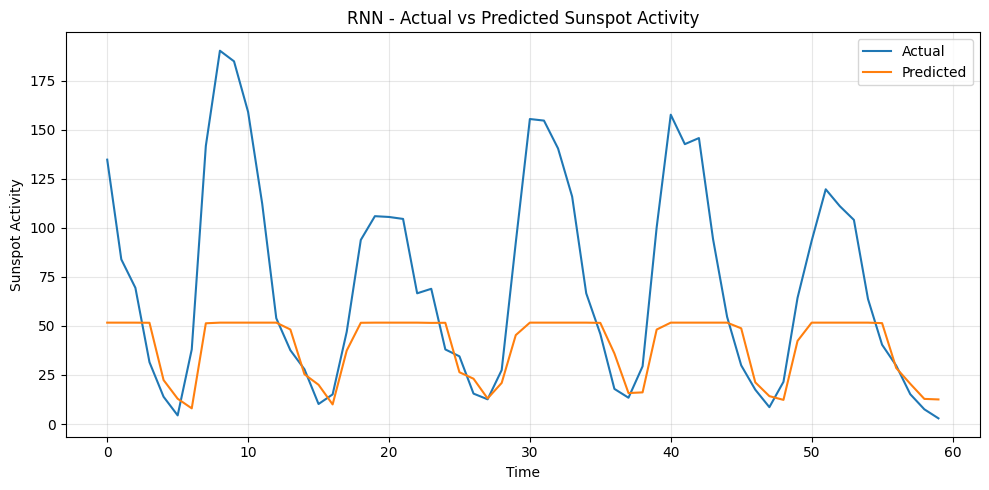

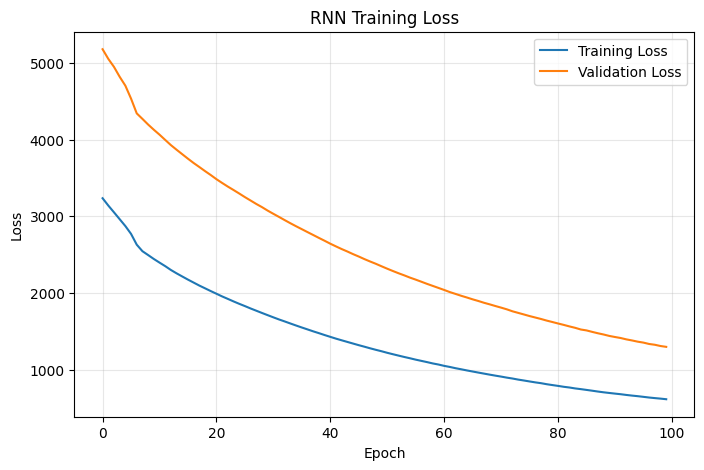

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)


# ============================================================
# LOAD SUNSPOTS DATASET
# ============================================================

data = sm.datasets.sunspots.load_pandas().data

print(data.head())
print("\nDataset Shape:", data.shape)


# Sunspot activity values
series = data["SUNACTIVITY"].values


# ============================================================
# CREATE SEQUENCES
# ============================================================

# Use previous 12 observations
# to predict the next observation

time_steps = 12

X = []
y = []

for i in range(len(series) - time_steps):

    X.append(
        series[i:i + time_steps]
    )

    y.append(
        series[i + time_steps]
    )


X = np.array(X)
y = np.array(y)


# RNN expects:
# samples, time_steps, features

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)


print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

split = int(
    len(X) * 0.80
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================================
# BUILD RNN MODEL
# ============================================================

model = Sequential([
    
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(
            time_steps,
            1
        )
    ),

    Dense(1)
])


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="mse"
)


# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,

    epochs=100,
    batch_size=16,

    validation_split=0.1,

    verbose=1
)


# ============================================================
# PREDICTION
# ============================================================

prediction = model.predict(
    X_test
).flatten()


# ============================================================
# EVALUATION
# ============================================================

mse = mean_squared_error(
    y_test,
    prediction
)

mae = mean_absolute_error(
    y_test,
    prediction
)


print("\n========== RNN RESULTS ==========")

print("MSE:", mse)
print("MAE:", mae)


# ============================================================
# ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    prediction,
    label="Predicted"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Sunspot Activity"
)

plt.title(
    "RNN - Actual vs Predicted Sunspot Activity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# TRAINING LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "RNN Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

 # Hidden Markov Model (HMM)

In [17]:
pip install hmmlearn statsmodels matplotlib

Note: you may need to restart the kernel to use updated packages.


     YEAR  SUNACTIVITY
0  1700.0          5.0
1  1701.0         11.0
2  1702.0         16.0
3  1703.0         23.0
4  1704.0         36.0

Dataset Shape: (309, 2)
HMM Input Shape: (309, 1)

HMM Training Completed

First 20 Hidden States:
[0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 2 2 1]

Transition Probability Matrix:
[[6.96998026e-01 3.03001974e-01 6.60082906e-16]
 [2.96004684e-01 4.27214601e-01 2.76780716e-01]
 [1.25191419e-22 2.16085129e-01 7.83914871e-01]]

State Means:
[[10.14853415]
 [36.46695209]
 [90.65893712]]

Initial State Probabilities:
[1.00000000e+000 1.07232614e-054 5.36259954e-185]

States from Low to High Activity:
[0 1 2]
State 0 Mean Activity: 10.15
State 1 Mean Activity: 36.47
State 2 Mean Activity: 90.66


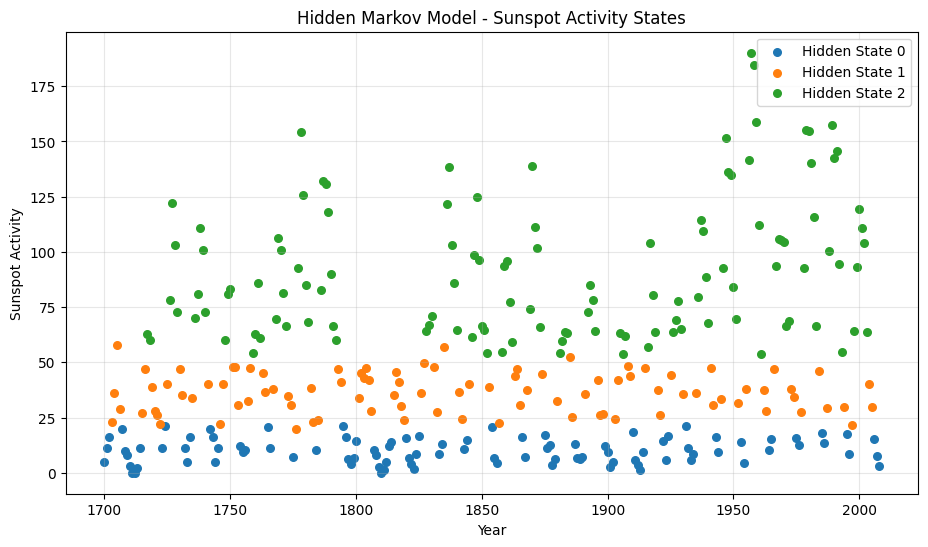

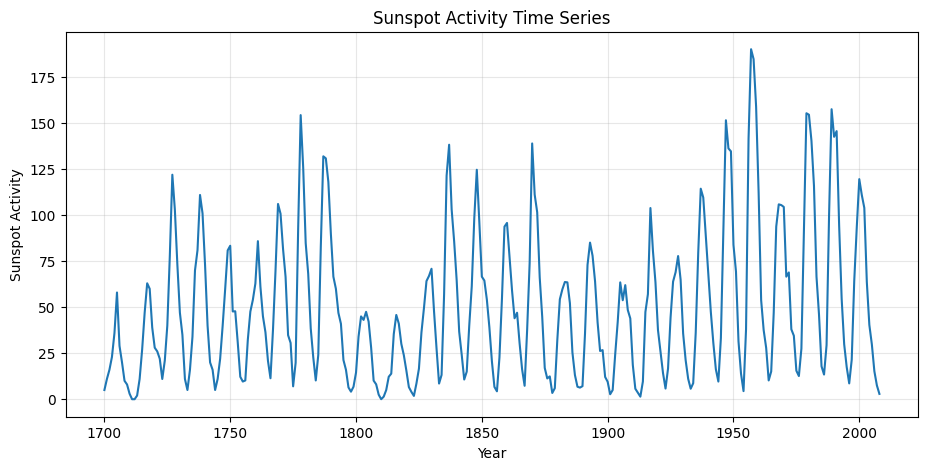

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from hmmlearn.hmm import GaussianHMM


# ============================================================
# LOAD SUNSPOTS DATASET
# ============================================================

data = sm.datasets.sunspots.load_pandas().data

years = data["YEAR"].values
sunspots = data["SUNACTIVITY"].values

print(data.head())
print("\nDataset Shape:", data.shape)


# ============================================================
# PREPARE DATA FOR HMM
# ============================================================

# HMM requires a 2D input:
# [samples, features]

X = sunspots.reshape(-1, 1)

print("HMM Input Shape:", X.shape)


# ============================================================
# CREATE HMM
# ============================================================

# We assume 3 hidden states:
# Low, Medium, High sunspot activity

model = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)


# ============================================================
# TRAIN MODEL
# ============================================================

model.fit(X)

print("\nHMM Training Completed")


# ============================================================
# PREDICT HIDDEN STATES
# ============================================================

hidden_states = model.predict(X)

print("\nFirst 20 Hidden States:")
print(hidden_states[:20])


# ============================================================
# MODEL INFORMATION
# ============================================================

print("\nTransition Probability Matrix:")
print(model.transmat_)

print("\nState Means:")
print(model.means_)

print("\nInitial State Probabilities:")
print(model.startprob_)


# ============================================================
# SORT STATES BY ACTIVITY LEVEL
# ============================================================

state_means = model.means_.flatten()

state_order = np.argsort(state_means)

print("\nStates from Low to High Activity:")
print(state_order)

for state in state_order:

    print(
        "State",
        state,
        "Mean Activity:",
        round(state_means[state], 2)
    )


# ============================================================
# VISUALIZE HIDDEN STATES
# ============================================================

plt.figure(figsize=(11, 6))

for state in range(model.n_components):

    mask = hidden_states == state

    plt.scatter(
        years[mask],
        sunspots[mask],
        label=f"Hidden State {state}",
        s=30
    )


plt.xlabel("Year")
plt.ylabel("Sunspot Activity")

plt.title(
    "Hidden Markov Model - Sunspot Activity States"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# ORIGINAL TIME SERIES
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    years,
    sunspots
)

plt.xlabel("Year")
plt.ylabel("Sunspot Activity")

plt.title(
    "Sunspot Activity Time Series"
)

plt.grid(alpha=0.3)

plt.show()

# LLM

In [19]:
pip install transformers datasets torch scikit-learn matplotlib

  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 5.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/12.1 MB 4.1 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.1 MB 4.5 MB/s eta 0:00:03
   ----------- ---------------------------- 3.4/12.1 MB 4.7 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.1 MB 4.5 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.1 MB 4.4 MB/s eta 0:00:02
   -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Number of samples: 500

Classes:
0 = Negative
1 = Positive


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


========== LLM RESULTS ==========
Accuracy: 90.6 %

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.91      0.95       500
    Positive       0.00      0.00      0.00         0

    accuracy                           0.91       500
   macro avg       0.50      0.45      0.48       500
weighted avg       1.00      0.91      0.95       500


========== EXAMPLE PREDICTIONS ==========

Review:
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab ...
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.9996

Review:
Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell  ...
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.6171

Review:
its a

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

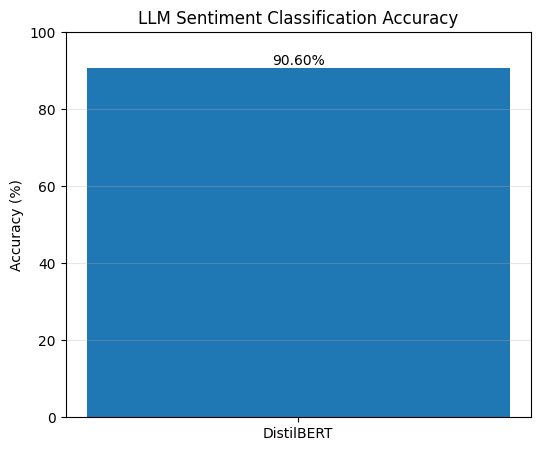

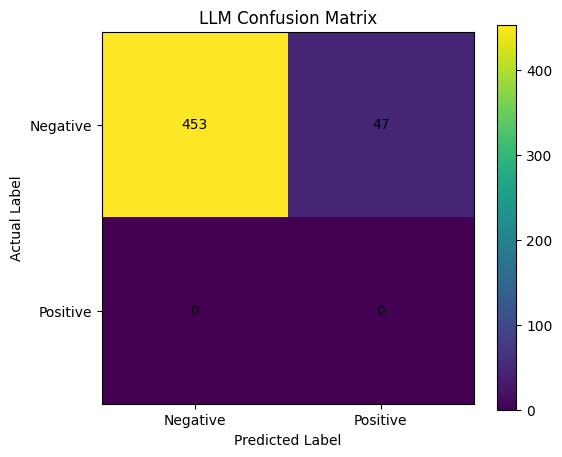

In [23]:
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# LOAD IMDb DATASET
# ============================================================

# Use 500 samples so the experiment runs quickly

dataset = load_dataset(
    "stanfordnlp/imdb",
    split="test[:500]"
)

texts = [str(text) for text in dataset["text"]]
true_labels = list(dataset["label"])

print("Number of samples:", len(texts))

print("\nClasses:")
print("0 = Negative")
print("1 = Positive")


# ============================================================
# LOAD PRETRAINED LANGUAGE MODEL
# ============================================================

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


# ============================================================
# MAKE PREDICTIONS
# ============================================================

predictions = classifier(
    texts,
    truncation=True,
    batch_size=16
)


# Convert model output to 0 / 1

predicted_labels = []

for prediction in predictions:

    if prediction["label"] == "POSITIVE":
        predicted_labels.append(1)

    else:
        predicted_labels.append(0)


# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print("\n========== LLM RESULTS ==========")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


print("\nClassification Report:")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)


# ============================================================
# EXAMPLE PREDICTIONS
# ============================================================

print("\n========== EXAMPLE PREDICTIONS ==========")

for i in range(5):

    print("\nReview:")
    print(texts[i][:200], "...")

    print(
        "Actual:",
        "Positive"
        if true_labels[i] == 1
        else "Negative"
    )

    print(
        "Predicted:",
        predictions[i]["label"]
    )

    print(
        "Confidence:",
        round(
            predictions[i]["score"],
            4
        )
    )


# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(6, 5)
)

plt.bar(
    ["DistilBERT"],
    [accuracy * 100]
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "LLM Sentiment Classification Accuracy"
)

plt.ylim(
    0,
    100
)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "LLM Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)


for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.show()